# 🛰️ Multi-Temporal Urban Growth & Nature Loss — Demo Notebook

This notebook walks through the **end-to-end pipeline** implemented in `src/` using the pre-cached **Warsaw** Sentinel-2 dataset (2018, 2022, 2025).

Each section calls into an existing pipeline module — no logic is re-implemented here.

**Pipeline stages**
1. Load raw multi-spectral Sentinel-2 arrays (`presets/raw_<year>.npy`)
2. ORB + RANSAC alignment to the oldest reference year (`src.alignment`)
3. Spectral enhancement — NDVI, HSV saturation, LAB CLAHE (`src.enhancement`)
4. Sliding-window 2D FFT texture maps (`src.fourier_analysis`)
5. Unsupervised K-Means segmentation + morphological cleanup (`src.segmentation`, `src.morphology`)
6. Multi-temporal urban / nature-loss / fractal report

## 1. Setup — imports and configuration

We make the project root importable, create a working `data/` directory, and pull in the pipeline modules. Matplotlib is set to render inline.

In [ ]:
!pip3 install -r requirements.txt

In [1]:
import os
import sys
import shutil
import numpy as np
import matplotlib.pyplot as plt

# Make sure the project root is on sys.path so `src.*` imports work
PROJECT_ROOT = os.path.abspath(".")
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

DATA_DIR = "data"
PRESETS_DIR = "presets"
YEARS = [2018, 2022, 2025]
BASE_YEAR = min(YEARS)
DISTANCE_KM = 10.0  # 10 km x 10 km Warsaw window @ 10 m/pixel -> 1000 x 1000

os.makedirs(DATA_DIR, exist_ok=True)
print(f"Project root : {PROJECT_ROOT}")
print(f"Data dir     : {DATA_DIR}")
print(f"Target years : {YEARS}")

Project root : /Users/nijatkazimli/urban_growth_analysis
Data dir     : data
Target years : [2018, 2022, 2025]


## 2. Stage Warsaw raw presets into `data/`

The repository ships pre-cached, validated Float32 multi-spectral arrays in `presets/`. We copy them into `data/` so downstream modules can read/write alongside them without ever touching the read-only master presets.

In [2]:
for yr in YEARS:
    src = os.path.join(PRESETS_DIR, f"raw_{yr}.npy")
    dst = os.path.join(DATA_DIR, f"raw_{yr}.npy")
    if not os.path.exists(src):
        raise FileNotFoundError(f"Missing preset: {src}")
    if not os.path.exists(dst):
        shutil.copy2(src, dst)
        print(f"✓ Copied {src} -> {dst}")
    else:
        print(f"✓ Already present: {dst}")

# Quick sanity check on shape: (H, W, 5) -> [R, G, B, NIR, dataMask]
sample = np.load(os.path.join(DATA_DIR, f"raw_{BASE_YEAR}.npy"))
print(f"\nRaw array shape for {BASE_YEAR}: {sample.shape}, dtype={sample.dtype}")

✓ Copied presets/raw_2018.npy -> data/raw_2018.npy
✓ Copied presets/raw_2022.npy -> data/raw_2022.npy
✓ Copied presets/raw_2025.npy -> data/raw_2025.npy

Raw array shape for 2018: (1000, 1000, 5), dtype=float32


## 3. Preview the raw RGB composites

Channels in each raw array are `[B04 Red, B03 Green, B02 Blue, B08 NIR, dataMask]`. We apply a simple ×2.5 visual gain and clip to `[0, 1]` to get a quick-look RGB for each year.

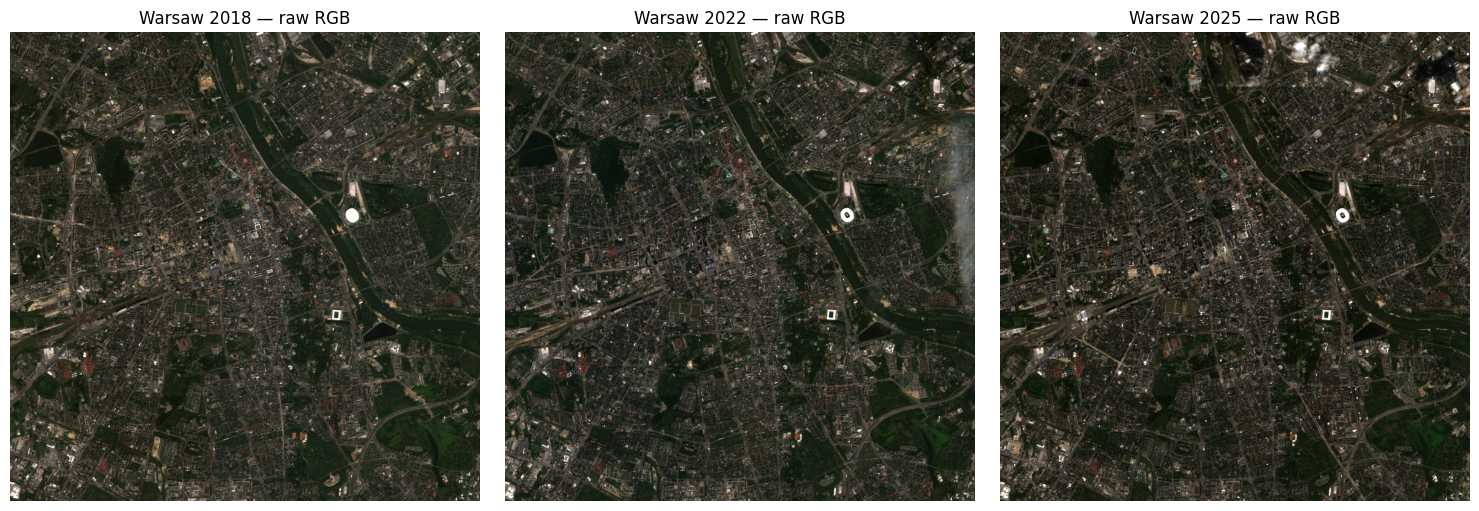

In [3]:
def quicklook_rgb(raw):
    """Apply a standard visual gain to Float32 reflectance for display."""
    return np.clip(raw[:, :, :3] * 2.5, 0.0, 1.0)

fig, axes = plt.subplots(1, len(YEARS), figsize=(15, 5))
for ax, yr in zip(axes, YEARS):
    raw = np.load(os.path.join(DATA_DIR, f"raw_{yr}.npy"))
    ax.imshow(quicklook_rgb(raw))
    ax.set_title(f"Warsaw {yr} — raw RGB")
    ax.axis("off")
plt.tight_layout()
plt.show()

## 4. Stage 1 — Sub-pixel alignment (ORB + RANSAC)

`src.alignment.register_and_align` extracts ORB keypoints from the grayscale of each year, matches them to the base year with a brute-force KNN + Lowe's ratio test, estimates a homography $\mathbf{H}$ with RANSAC, and warps all 5 channels of the target onto the base frame. The base year is saved as `aligned_<base>.npy` directly.

In [6]:
from src.alignment import register_and_align

base_raw = np.load(os.path.join(DATA_DIR, f"raw_{BASE_YEAR}.npy"))
np.save(os.path.join(DATA_DIR, f"aligned_{BASE_YEAR}.npy"), base_raw)
print(f"✓ Saved baseline aligned_{BASE_YEAR}.npy")

for yr in YEARS:
    if yr == BASE_YEAR:
        continue
    target_raw = np.load(os.path.join(DATA_DIR, f"raw_{yr}.npy"))
    register_and_align(base_raw, target_raw, yr, DATA_DIR)

✓ Saved baseline aligned_2018.npy

--- Aligning Satellite Image for Year 2022 to 2018 Base ---
Detected 3000 keypoints in 2018, 3000 in 2022.
Found 539 high-quality matches after Lowe's ratio test.
RANSAC Homography estimated with 532 inliers (98.7%).
Saved aligned multi-spectral array to data/aligned_2022.npy
Saved registration visual report to data/alignment_check_2022.png

--- Aligning Satellite Image for Year 2025 to 2018 Base ---
Detected 3000 keypoints in 2018, 3000 in 2025.
Found 292 high-quality matches after Lowe's ratio test.
RANSAC Homography estimated with 286 inliers (97.9%).
Saved aligned multi-spectral array to data/aligned_2025.npy
Saved registration visual report to data/alignment_check_2025.png


## 5. Stage 2 — Spectral enhancement (NDVI, Saturation, CLAHE)

`src.enhancement.process_enhancements` computes and persists:

- **NDVI** $= (\text{NIR} - \text{Red}) / (\text{NIR} + \text{Red})$ — vegetation vigour
- **HSV Saturation** — separates concrete (low) from foliage (high)
- **LAB CLAHE** — contrast-equalises the luminance channel for street/grid visibility

In [7]:
from src.enhancement import process_enhancements

for yr in YEARS:
    process_enhancements(yr, DATA_DIR)


--- Processing Spectral & Image Enhancements for Year 2018 ---
Calculated and saved NDVI to ndvi_2018.npy
Calculated and saved Saturation to saturation_2018.npy
Calculated and saved CLAHE enhanced image to visual_clahe_2018.png
Saved spectral enhancement visual report to data/enhancements_report_2018.png

--- Processing Spectral & Image Enhancements for Year 2022 ---
Calculated and saved NDVI to ndvi_2022.npy
Calculated and saved Saturation to saturation_2022.npy
Calculated and saved CLAHE enhanced image to visual_clahe_2022.png
Saved spectral enhancement visual report to data/enhancements_report_2022.png

--- Processing Spectral & Image Enhancements for Year 2025 ---
Calculated and saved NDVI to ndvi_2025.npy
Calculated and saved Saturation to saturation_2025.npy
Calculated and saved CLAHE enhanced image to visual_clahe_2025.png
Saved spectral enhancement visual report to data/enhancements_report_2025.png


### 5a. Visualise NDVI across years

Green = vigorous vegetation (NDVI → 1), brown/red = built-up or bare (NDVI → 0 or negative).

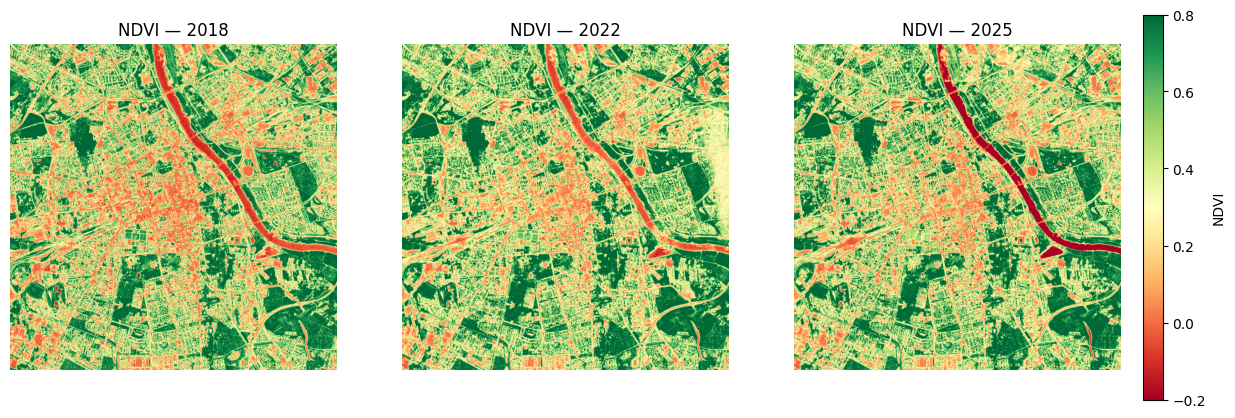

In [8]:
fig, axes = plt.subplots(1, len(YEARS), figsize=(15, 5))
for ax, yr in zip(axes, YEARS):
    ndvi = np.load(os.path.join(DATA_DIR, f"ndvi_{yr}.npy"))
    im = ax.imshow(ndvi, cmap="RdYlGn", vmin=-0.2, vmax=0.8)
    ax.set_title(f"NDVI — {yr}")
    ax.axis("off")
fig.colorbar(im, ax=axes, fraction=0.025, pad=0.02, label="NDVI")
plt.show()

## 6. Stage 3 — Sliding-window 2D FFT texture

`src.fourier_analysis.process_fourier_analysis` slides a $64 \times 64$ window across the grayscale image, applies a 2D Hanning taper, takes a centred 2D FFT, and sums the magnitude in the mid–high-frequency annulus ($5 \le r \le 30$ px). The resulting low-resolution map is bicubically up-sampled to the original grid. High values → repeating man-made grids; low values → isotropic nature.


--- Running Fourier Spatial Frequency Analysis for Year 2018 ---
Calculating local 2D FFT sliding window energy map (this may take a few seconds)...
Saved localized Fourier Texture Map to data/fourier_2018.npy
Saved Fourier visual map to data/visual_fourier_2018.png
Saved Fourier Spectrum comparison diagnostic to data/fourier_diagnostics_2018.png

--- Running Fourier Spatial Frequency Analysis for Year 2022 ---
Calculating local 2D FFT sliding window energy map (this may take a few seconds)...
Saved localized Fourier Texture Map to data/fourier_2022.npy
Saved Fourier visual map to data/visual_fourier_2022.png
Saved Fourier Spectrum comparison diagnostic to data/fourier_diagnostics_2022.png

--- Running Fourier Spatial Frequency Analysis for Year 2025 ---
Calculating local 2D FFT sliding window energy map (this may take a few seconds)...
Saved localized Fourier Texture Map to data/fourier_2025.npy
Saved Fourier visual map to data/visual_fourier_2025.png
Saved Fourier Spectrum compariso

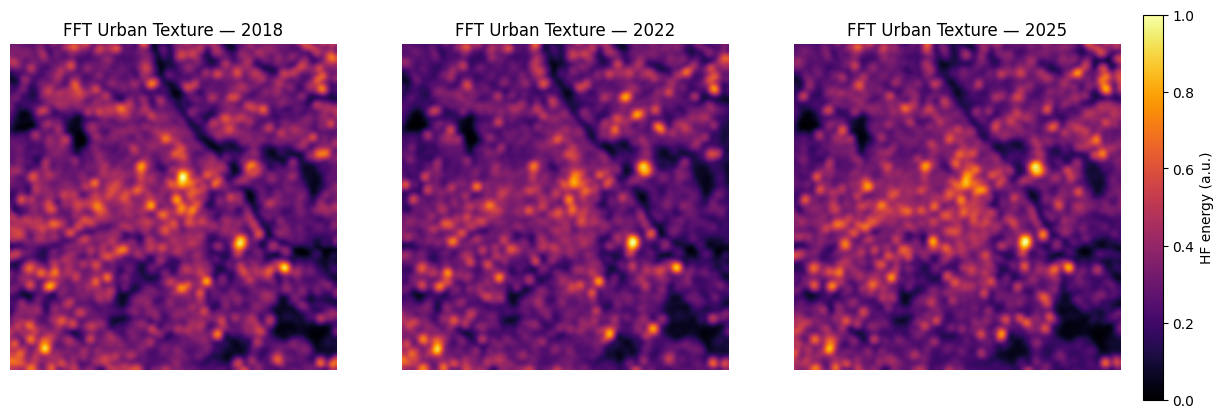

In [9]:
from src.fourier_analysis import process_fourier_analysis

for yr in YEARS:
    process_fourier_analysis(yr, DATA_DIR)

# Quick visual of the FFT urban-texture index across years
fig, axes = plt.subplots(1, len(YEARS), figsize=(15, 5))
for ax, yr in zip(axes, YEARS):
    fourier = np.load(os.path.join(DATA_DIR, f"fourier_{yr}.npy"))
    im = ax.imshow(fourier, cmap="inferno")
    ax.set_title(f"FFT Urban Texture — {yr}")
    ax.axis("off")
fig.colorbar(im, ax=axes, fraction=0.025, pad=0.02, label="HF energy (a.u.)")
plt.show()

## 7. Stage 4 — Unsupervised K-Means segmentation

`src.segmentation.run_multi_spectral_segmentation` stacks every pixel into a **7-D feature vector** `[R, G, B, NIR, NDVI, FFT-texture, Saturation]`, runs `KMeans(n_clusters=3)`, and deterministically labels the resulting clusters:

- Highest mean NDVI → **Forest / Nature**
- Lowest mean NIR → **Water**
- Remaining → **Urban**

Masks are then cleaned with disk-shaped morphological open/close (`src.morphology`), and shape descriptors plus a box-counting fractal dimension are computed (`src.descriptors`). Results per year are collected for the final report.

In [10]:
from src.segmentation import run_multi_spectral_segmentation

results = {}
for yr in YEARS:
    results[yr] = run_multi_spectral_segmentation(yr, DATA_DIR)


--- Running Multi-Spectral Segmentation for Year 2018 ---
Fitting unsupervised K-Means model on 1,000,000 pixel stack...
Auto-mapped Clusters -> Forest: Cluster 2 | Water: Cluster 1 | Urban: Cluster 0
Applying morphological opening/closing filters to refine spatial borders...
Saved final classified array to classified_2018.npy

--- Land Cover Statistics ---
Urban Area: 29.38 sq km (29.38%)
Forest/Vegetation Area: 32.18 sq km (32.18%)
Water Coverage: 37.95 sq km (37.95%)

--- Extracting Shape & Fractal Feature Descriptors for Year 2018 ---
Detected 172 discrete urban sprawl patches (area >= 15 px).
Global Boundary Fractal Dimension: 1.8767
Largest Core Area: 26.92 sq km
Average Circularity: 0.447 | Average Solidity: 0.748
Saved feature descriptors visual report to data/descriptors_analysis_2018.png
Saved land cover classification visual report to data/segmentation_report_2018.png

--- Running Multi-Spectral Segmentation for Year 2022 ---
Fitting unsupervised K-Means model on 1,000,000 

### 7a. Visualise the classified land-cover maps

The persisted `classified_<year>.npy` arrays carry integer class IDs. We render them with a fixed palette so colours are comparable across years.

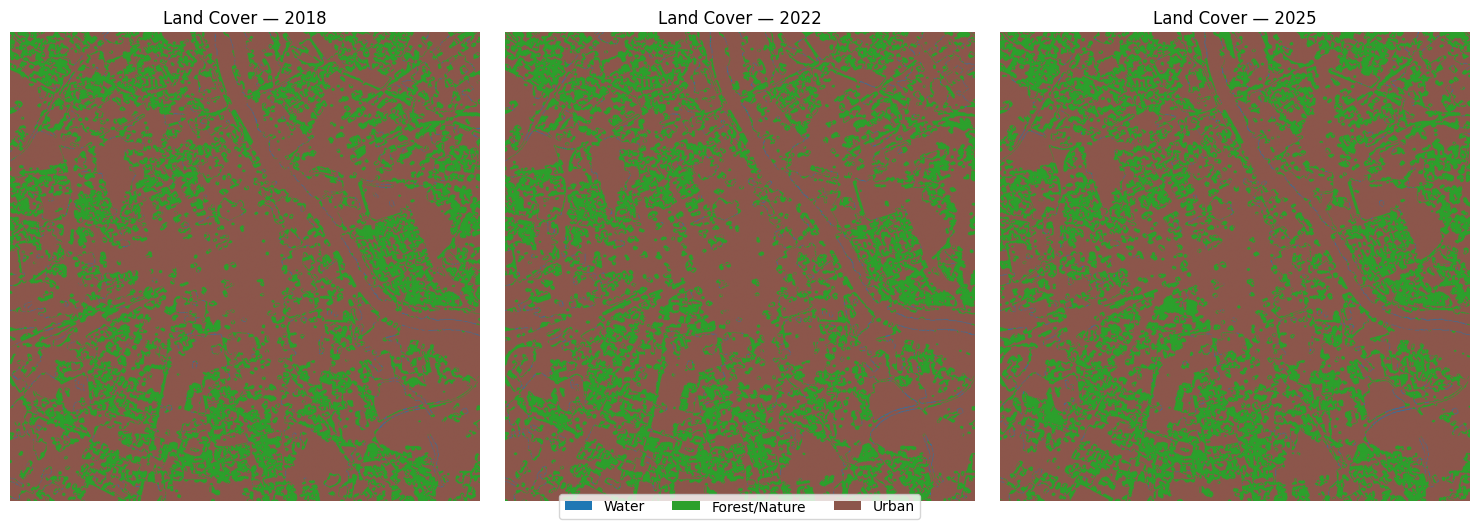

In [11]:
from matplotlib.colors import ListedColormap

# Class id convention used by src.segmentation: 0=Water, 1=Forest, 2=Urban
cmap = ListedColormap(["#1f77b4", "#2ca02c", "#8c564b"])  # water, forest, urban
labels = ["Water", "Forest/Nature", "Urban"]

fig, axes = plt.subplots(1, len(YEARS), figsize=(15, 5))
for ax, yr in zip(axes, YEARS):
    classified = np.load(os.path.join(DATA_DIR, f"classified_{yr}.npy"))
    ax.imshow(classified, cmap=cmap, vmin=0, vmax=2)
    ax.set_title(f"Land Cover — {yr}")
    ax.axis("off")

# Manual legend
from matplotlib.patches import Patch
handles = [Patch(facecolor=c, label=l) for c, l in zip(cmap.colors, labels)]
fig.legend(handles=handles, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.show()

## 8. Multi-temporal urban-sprawl & nature-loss report

Using the dictionaries returned by the segmentation stage, we tabulate:

- **Urban area** (km²) and **urban %** of the study window
- **Nature loss** relative to the base year — `forest_km2(base) − forest_km2(year)`
- **Boundary fractal dimension** of the urban fringe (box-counting, `src.descriptors`)

In [12]:
base_forest = results[BASE_YEAR]["forest_km2"]

print("=" * 75)
print("           MULTI-TEMPORAL URBAN SPRAWL SUMMARY (Warsaw)")
print("=" * 75)
print(f"{'Year':<6} | {'Urban (km2)':<12} | {'Urban %':<8} | {'Nature loss (km2)':<18} | {'Fractal D':<10}")
print("-" * 75)
for yr in sorted(results):
    r = results[yr]
    loss = 0.0 if yr == BASE_YEAR else base_forest - r["forest_km2"]
    print(f"{yr:<6} | {r['urban_km2']:<12.2f} | {r['urban_pct']:<8.2f} | {loss:<18.2f} | {r['fractal_dimension']:<10.4f}")
print("=" * 75)

           MULTI-TEMPORAL URBAN SPRAWL SUMMARY (Warsaw)
Year   | Urban (km2)  | Urban %  | Nature loss (km2)  | Fractal D 
---------------------------------------------------------------------------
2018   | 29.38        | 29.38    | 0.00               | 1.8767    
2022   | 29.85        | 29.85    | 0.78               | 1.8788    
2025   | 33.23        | 33.23    | 2.79               | 1.8753    


### 8a. Quick urban-growth chart

In [ ]:
years_sorted = sorted(results)
urban_km2 = [results[y]["urban_km2"] for y in years_sorted]
forest_km2 = [results[y]["forest_km2"] for y in years_sorted]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(years_sorted, urban_km2, marker="o", color="#8c564b", label="Urban km²")
ax.plot(years_sorted, forest_km2, marker="s", color="#2ca02c", label="Forest/Nature km²")
ax.set_xlabel("Year")
ax.set_ylabel("Area (km²)")
ax.set_title("Warsaw — urban expansion vs. nature loss")
ax.set_xticks(years_sorted)
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## 9. Next steps

- Re-run with a custom study area using `main.py --dataset custom --lat ... --lon ... --distance ... --years ...` (requires Sentinel Hub credentials in `.env`).
- Inspect the `data/` directory: every intermediate stage (`aligned_*.npy`, `ndvi_*.npy`, `fourier_*.npy`, `classified_*.npy`, plus diagnostic PNGs) is persisted for further analysis.
- Tweak `KMeans` cluster count or feature stack in `src/segmentation.py` to experiment with finer land-cover taxonomies.